In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import os

In [5]:
df = pd.read_csv('../data/city_lifestyle_dataset.csv')
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


### Préparation des données

In [6]:
# On enlève les noms de villes et pays
X = df.drop(['city_name', 'country'], axis=1)
X.head()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [10]:
# On standardise les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Application du t-SNE

In [13]:
# On applique le t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

### Visualisation

In [21]:
# On convertit les noms de pays (texte) en codes numériques
pays_numeriques = df['country'].astype('category').cat.codes

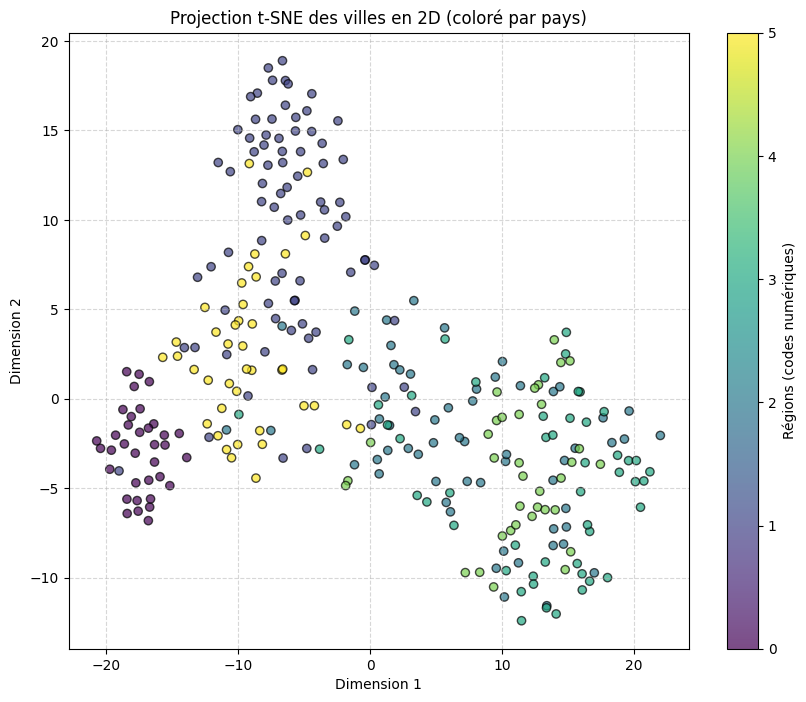

In [31]:
# On visualise les données en 2 dimensions par pays
plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, c=pays_numeriques, cmap='viridis', edgecolors='k')

plt.title('Projection t-SNE des villes en 2D (coloré par pays)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.colorbar(scatter, label='Régions (codes numériques)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Interprétation : 

L'algorithme t-SNE que l'on a lancé a projeté nos données multidimensionnelles en 2D en regroupant les villes selon leurs similarités. En colorant ces points par continent, on observe que le graphique forme plusieurs clusters de points distincts. Cependant, on remarque que les couleurs (les régions) sont parfois mélangées au sein d'un même cluster. Cela prouve que le profil d'une ville dépend de son développement et pas uniquement de son continent.

Il y a aussi des similarités transcontinentales : une mégalopole très dense en Asie peut se retrouver très proche géométriquement d'un grand pôle technologique en Amérique du Nord sur le graphique, car leurs caractéristiques (loyers élevés, forte densité, etc) se ressemblent énormément.

Malgré ce mélange, on observe tout de même que certaines couleurs dominent certains espaces du graphique. Par exemple, les régions ayant des caractéristiques de base similaires (comme l'Europe avec de forts revenus et de bonnes infrastructures) ont tendance à se concentrer dans des zones spécifiques de la projection.

In [29]:
# On exporte les données en 2 dimensions
os.makedirs('../outputs', exist_ok=True)  ## on verifie si les outputs existent
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['city'] = df['city_name']
df_tsne['country'] = df['country']
df_tsne.to_csv('../outputs/tsne_export.csv', index=False)

In [30]:
df_tsne.head()

,Dim1,Dim2,city,country
0,9.556017,-9.478044,Old Vista,Europe
1,8.369970,-4.689763,Beachport,Europe
2,15.534404,-2.767016,Valleyborough,Europe
3,8.060909,0.540094,City,Europe
4,19.271635,-2.253153,Falls,Europe
